In [ ]:
import subprocess, os, sys, json, re, time
from pathlib import Path

def banner(t): print("\n" + "═"*72 + f"\n  {t}\n" + "═"*72)
def sh(cmd, quiet=False, check=False):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if not quiet:
        if r.stdout: print(r.stdout.rstrip()[:4000])
        if r.returncode and r.stderr: print("[stderr]", r.stderr.rstrip()[:1500], file=sys.stderr)
    if check and r.returncode: raise RuntimeError(cmd)
    return r

banner("STEP 1 — Install FLOSS + MinGW-w64")
sh("pip install -q flare-floss")
sh("apt-get -qq update && apt-get -qq install -y mingw-w64 binutils-mingw-w64", quiet=True)
sh("floss --version 2>&1 | head -3")

In [ ]:
banner("STEP 2 — Build a synthetic malware-like PE")
WORK = Path("/content/floss_tutorial"); WORK.mkdir(exist_ok=True); os.chdir(WORK)

SECRETS = [
    ("FAKE_FLAG_DECODED_SECRET",                0x37),
    ("https://c2-totally-fake.example/beacon",  0x42),
    ("SOFTWARE\\Microsoft\\Run\\PersistDemo",   0x5A),
    ("kernel32.dll!VirtualAllocEx",             0x29),
]
def xor_arr(s, k): return ",".join(f"0x{(ord(c)^k)&0xff:02x}" for c in s)

c = [
    '#include <stdio.h>',
    '__attribute__((noinline)) static void xord(char* b, int n, int k){',
    '    for(int i=0;i<n;i++) b[i] ^= (char)k;',
    '}',
    'int main(void){',
    '    puts("PLAIN_STATIC_HELLO_FROM_FLOSS_TUTORIAL");',
    '',
    '    volatile char stk[20];',
]
seq = "STACK_BUILT_STRING"
for i, ch in enumerate(seq): c.append(f"    stk[{i}]='{ch}';")
c += [f"    stk[{len(seq)}]=0;", "    puts((char*)stk);", "",
      "    volatile char tght[]={'T','I','G','H','T','-','S','T','R',0};",
      "    puts((char*)tght);", ""]
for i,(s,k) in enumerate(SECRETS):
    c += [f"    char enc{i}[] = {{ {xor_arr(s,k)}, 0x00 }};",
          f"    xord(enc{i}, {len(s)}, 0x{k:02x});",
          f"    puts(enc{i});"]
c += ["    return 0;", "}"]
(WORK/"sample.c").write_text("\n".join(c))
sh("x86_64-w64-mingw32-gcc -O0 -fno-stack-protector -o sample.exe sample.c -static-libgcc", check=True)
print(f"\n✓ sample.exe built ({(WORK/'sample.exe').stat().st_size:,} bytes)")
sh("file sample.exe")

In [ ]:
banner("STEP 3 — Classic `strings` baseline (what gets MISSED)")
classic = set(subprocess.run("strings -a -n 6 sample.exe", shell=True,
              capture_output=True, text=True).stdout.splitlines())
print(f"`strings` extracted {len(classic):,} candidates total.")
print("Coverage of our planted secrets in plain `strings`:")
planted = ["PLAIN_STATIC_HELLO_FROM_FLOSS_TUTORIAL", "STACK_BUILT_STRING", "TIGHT-STR"] + [s for s,_ in SECRETS]
for s in planted:
    hit = any(s in line for line in classic)
    print(f"  {'✓ FOUND ' if hit else '✗ MISSED'}  {s}")

banner("STEP 4 — Run FLOSS (vivisect static + emulation; ~30–90 s)")
t0 = time.time()
sh("floss --json sample.exe > floss.json 2> floss.log")
print(f"\n[FLOSS finished in {time.time()-t0:.1f}s]")
print("--- last lines of FLOSS log ---")
sh("tail -15 floss.log")

In [ ]:
banner("STEP 5 — Parse FLOSS JSON output")
with open("floss.json") as f: data = json.load(f)

def extract(key):
    out = []
    for e in data.get("strings", {}).get(key, []):
        if isinstance(e, dict): out.append(e)
        else: out.append({"string": e})
    return out

static_s, stack_s = extract("static_strings"), extract("stack_strings")
tight_s,  decoded_s = extract("tight_strings"),  extract("decoded_strings")
buckets = {"static": static_s, "stack": stack_s, "tight": tight_s, "decoded": decoded_s}

print(f"  metadata.version : {data.get('metadata', {}).get('version','?')}")
for k,v in buckets.items(): print(f"  {k+'_strings':<17}: {len(v):>5}")

print("\nDecoded strings recovered (with decoder routine info):")
for e in decoded_s:
    s = e.get("string","")
    rtn = e.get("decoding_routine"); addr = e.get("address")
    rtn_s = f"0x{rtn:x}" if isinstance(rtn,int) else str(rtn)
    addr_s = f"0x{addr:x}" if isinstance(addr,int) else str(addr)
    print(f"  decoder={rtn_s:<12} at={addr_s:<12} → {s!r}")
print("\nStack / tight strings recovered:")
for e in stack_s + tight_s: print(f"  → {e.get('string','')!r}")


════════════════════════════════════════════════════════════════════════
  STEP 1 — Install FLOSS + MinGW-w64
════════════════════════════════════════════════════════════════════════
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.6/334.6 kB 16.7 MB/s eta 0:00:00
floss 3.1.1

════════════════════════════════════════════════════════════════════════
  STEP 2 — Build a synthetic malware-like PE
════════════════════════════════════════════════════════════════════════

✓ sample.exe built (297,507 bytes)
sample.exe: PE32+ executable (console) x86-64, for MS Windows

═════════════════════════════════════════

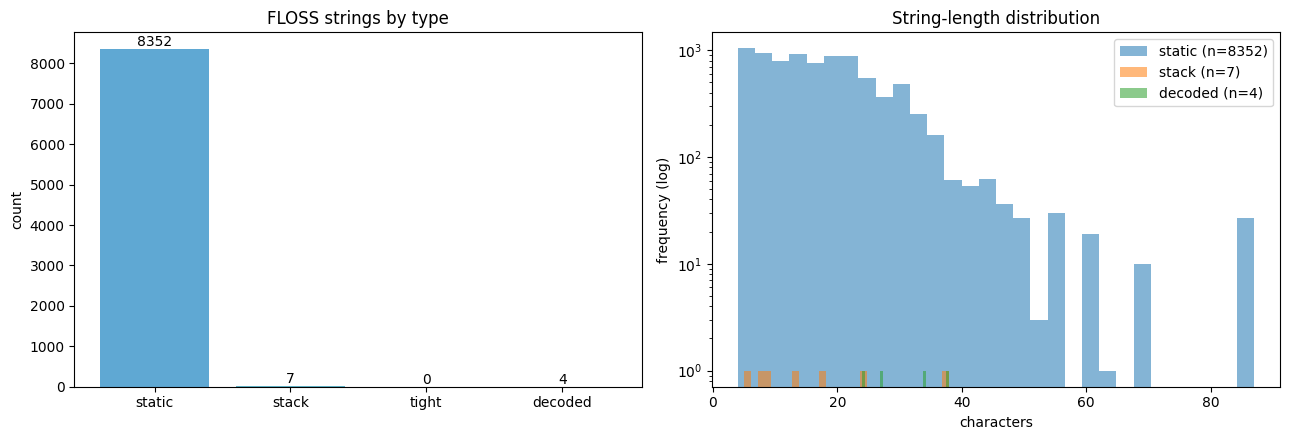


✓ Tutorial complete.
   Artifacts: /content/floss_tutorial/sample.exe, /content/floss_tutorial/floss.json, /content/floss_tutorial/floss_summary.png


In [1]:
banner("STEP 6 — IOC hunting in the deobfuscated strings")
PATTERNS = [
    ("URL",          re.compile(r"https?://[^\s\"<>]+")),
    ("IP",           re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")),
    ("PE/script",    re.compile(r"[A-Za-z0-9_]+\.(?:exe|dll|sys|ps1|bat)\b", re.I)),
    ("Win32 API",    re.compile(r"\b(?:Reg(?:Open|Set|Create|Delete)Key(?:Ex)?A?|VirtualAlloc(?:Ex)?|CreateRemoteThread|WinExec|LoadLibraryA?|GetProcAddress|InternetOpenA?)\b")),
    ("Registry",     re.compile(r"SOFTWARE\\\\?[A-Za-z0-9_\\\\]+", re.I)),
    ("Base64-like",  re.compile(r"\b[A-Za-z0-9+/]{24,}={0,2}\b")),
]
hits = []
for kind, items in buckets.items():
    for e in items:
        s = e.get("string","")
        for label, pat in PATTERNS:
            if pat.search(s): hits.append((kind, label, s))

if hits:
    print(f"{'BUCKET':<10}{'IOC':<14}STRING")
    print("-"*72)
    for kind,lbl,s in hits[:40]:
        print(f"{kind:<10}{lbl:<14}{s[:80]}")
    print(f"\n→ {len(hits)} IOC hits total. Note: most are inside the 'decoded' bucket")
    print("  — those would be invisible to plain `strings`!")
else:
    print("(no IOC pattern matches)")

banner("STEP 7 — Visualize string-type counts and length distribution")
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

labels = list(buckets); counts = [len(v) for v in buckets.values()]
bars = ax1.bar(labels, counts, color=["#5fa8d3","#62b6cb","#cae9ff","#ff7b7b"])
ax1.set_title("FLOSS strings by type"); ax1.set_ylabel("count")
for b,n in zip(bars,counts): ax1.text(b.get_x()+b.get_width()/2, n, str(n), ha="center", va="bottom")

for kind, items in buckets.items():
    lens = [len(e.get("string","")) for e in items]
    if lens: ax2.hist(lens, bins=30, alpha=0.55, label=f"{kind} (n={len(lens)})")
ax2.set_title("String-length distribution"); ax2.set_xlabel("characters")
ax2.set_ylabel("frequency (log)"); ax2.set_yscale("log"); ax2.legend()
plt.tight_layout(); plt.savefig("floss_summary.png", dpi=110); plt.show()

print("\n✓ Tutorial complete.")
print(f"   Artifacts: {WORK/'sample.exe'}, {WORK/'floss.json'}, {WORK/'floss_summary.png'}")